In [32]:
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
df = pd.read_csv("city-sports-merged.csv")
df


,Team_Name,City,From,To,W,L,Win_Percentage,Years_In_Playoffs,Championships,Championships_Conference,Championships_Division
0,Cardinals,Arizona,1920,2026,596,826,0.419,11,0,1,8
1,Falcons,Atlanta,1966,2026,406,521,0.438,14,0,2,7
2,Ravens,Baltimore,1996,2026,276,208,0.570,16,2,2,8
3,Bills,Buffalo,1960,2026,498,510,0.494,25,0,4,16
4,Panthers,Carolina,1995,2026,227,273,0.454,9,0,2,7
...,...,...,...,...,...,...,...,...,...,...,...
87,Kings,Sacramento,1948,2025,2810,3359,0.456,30,1,0,6
88,Spurs,San Antonio,1967,2025,2779,1996,0.582,48,5,6,22
89,Raptors,Toronto,1995,2025,1172,1302,0.474,14,1,1,7
90,Jazz,Utah,1974,2025,2216,1980,0.528,31,0,2,11


In [34]:
city_grouped = (
    df.groupby("City", as_index=False).agg({"Team_Name": "count",'Win_Percentage': 'mean',"Championships": "sum","Championships_Conference": "sum","Championships_Division": "sum","Years_In_Playoffs": "sum"}))


In [35]:
city_grouped.head(10)

,City,Team_Name,Win_Percentage,Championships,Championships_Conference,Championships_Division,Years_In_Playoffs
0,Arizona,2,0.454000,1,3,13,18
1,Atlanta,3,0.478667,5,20,42,94
2,Baltimore,2,0.522500,5,9,18,32
3,Boston,2,0.557500,27,25,45,89
4,Brooklyn,1,0.434000,2,2,5,31
5,Buffalo,1,0.494000,0,4,16,25
6,Carolina,1,0.454000,0,2,7,9
7,Charlotte,1,0.430000,0,0,0,11
8,Chicago,4,0.517750,13,31,48,97
9,Cincinnati,2,0.479500,5,13,22,33


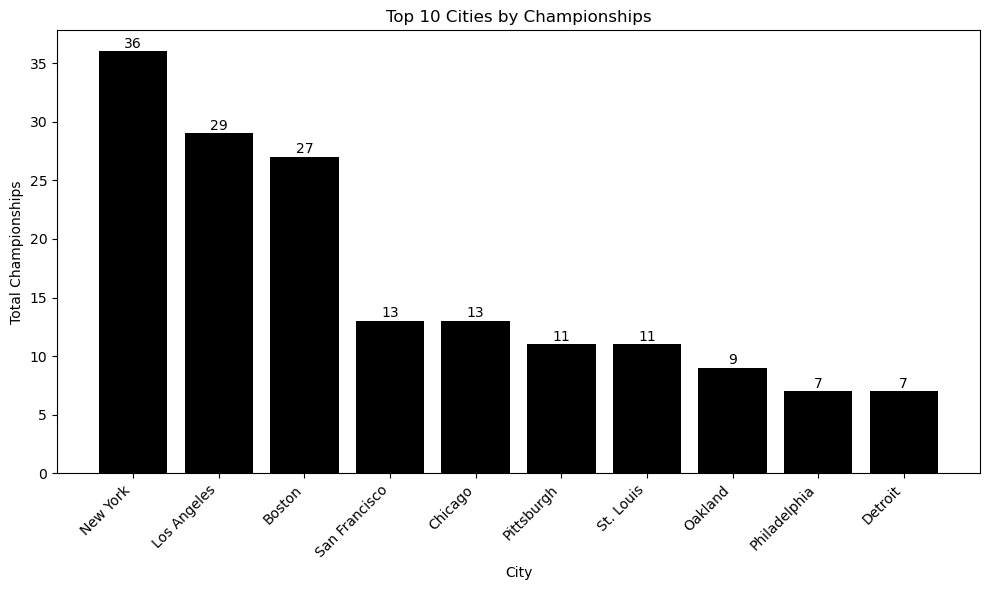

In [49]:
top10 = city_grouped.sort_values(by="Championships", ascending=False).head(10).copy()

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(top10["City"], top10["Championships"], color='black')
ax1.set_xlabel("City")
ax1.set_ylabel("Total Championships")
ax1.set_title("Top 10 Cities by Championships")
plt.xticks(rotation=45, ha="right")

for i, v in enumerate(top10["Championships"]):
    ax1.text(i, v + 0.3, str(v), ha="center")



plt.tight_layout()
plt.show()

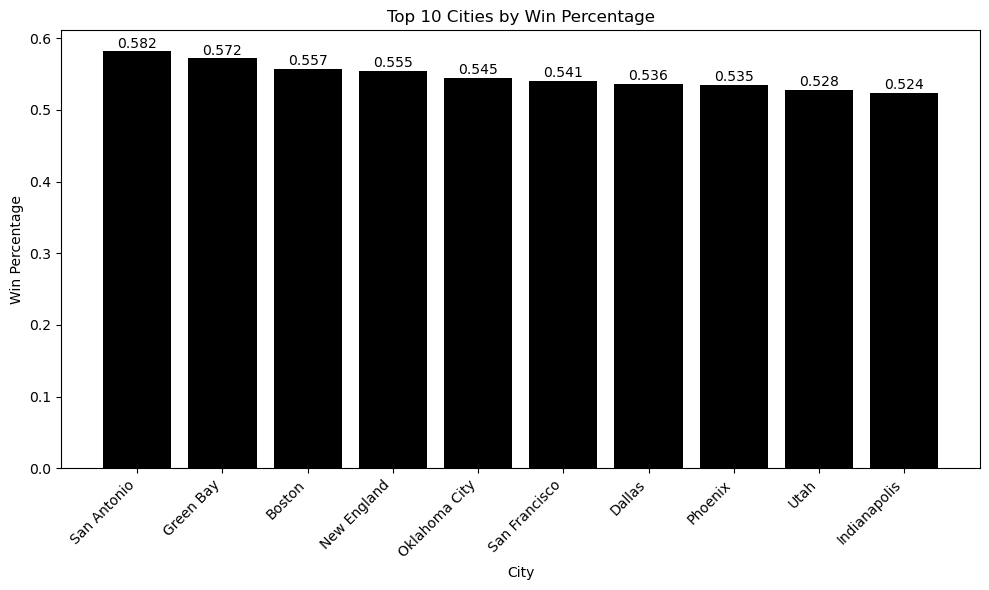

In [55]:
top10_win = city_grouped.sort_values(by="Win_Percentage", ascending=False).head(10).copy()

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(top10_win["City"], top10_win["Win_Percentage"], color='black')
ax1.set_xlabel("City")
ax1.set_ylabel("Win Percentage")
ax1.set_title("Top 10 Cities by Win Percentage")
plt.xticks(rotation=45, ha="right")

for i, v in enumerate(top10_win["Win_Percentage"]):
    ax1.text(i, v + 0.005, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

In [56]:
city_grouped.head()

,City,Team_Name,Win_Percentage,Championships,Championships_Conference,Championships_Division,Years_In_Playoffs
0,Arizona,2,0.454000,1,3,13,18
1,Atlanta,3,0.478667,5,20,42,94
2,Baltimore,2,0.522500,5,9,18,32
3,Boston,2,0.557500,27,25,45,89
4,Brooklyn,1,0.434000,2,2,5,31


In [66]:
city_scores = city_grouped.copy()

score_columns = [
    "Win_Percentage",
    "Championships",
    "Championships_Conference",
    "Championships_Division",
    "Years_In_Playoffs"
]

for col in score_columns:
    city_scores[col + "_Score"] = (
        (city_scores[col] - city_scores[col].min()) /
        (city_scores[col].max() - city_scores[col].min())
    ) * 100

city_scores["Best_Sports_City_Score"] = (
    city_scores["Win_Percentage_Score"] * 0.50 +
    city_scores["Championships_Score"] * 0.20 +
    city_scores["Championships_Conference_Score"] * 0.1 +
    city_scores["Championships_Division_Score"] * 0.1 +
    city_scores["Years_In_Playoffs_Score"] * 0.1
)

city_scores = city_scores.sort_values(
    by="Best_Sports_City_Score",
    ascending=False
)

city_scores.head(10)

,City,Team_Name,Win_Percentage,Championships,Championships_Conference,Championships_Division,Years_In_Playoffs,Win_Percentage_Score,Championships_Score,Championships_Conference_Score,Championships_Division_Score,Years_In_Playoffs_Score,Best_Sports_City_Score
23,Los Angeles,6,0.509833,29,53,106,191,52.832244,80.555556,94.642857,100.000000,100.000000,71.991519
3,Boston,2,0.557500,27,25,45,89,83.986928,75.000000,44.642857,42.452830,45.161290,70.219162
30,New York,5,0.499000,36,56,64,165,45.751634,100.000000,100.000000,60.377358,86.021505,67.515703
39,San Antonio,1,0.582000,5,6,22,48,100.000000,13.888889,10.714286,20.754717,23.118280,58.236506
41,San Francisco,2,0.541000,13,31,32,58,73.202614,36.111111,55.357143,30.188679,28.494624,55.227574
16,Green Bay,1,0.572000,4,5,31,38,93.464052,11.111111,8.928571,29.245283,17.741935,54.545827
8,Chicago,4,0.517750,13,31,48,97,58.006536,36.111111,55.357143,45.283019,49.462366,51.235743
28,New England,1,0.555000,6,12,23,29,82.352941,16.666667,21.428571,21.698113,12.903226,50.112795
12,Dallas,2,0.536500,6,11,31,61,70.261438,16.666667,19.642857,29.245283,30.107527,46.363619
36,Pittsburgh,2,0.519000,11,17,35,53,58.823529,30.555556,30.357143,33.018868,25.806452,44.441122


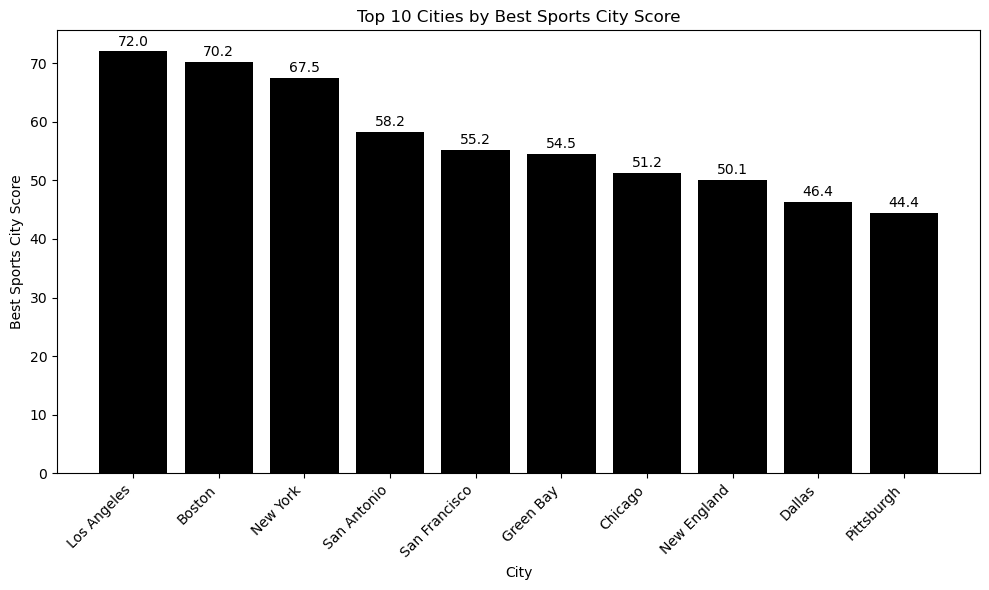

In [67]:
top10_score = city_scores.sort_values(by="Best_Sports_City_Score", ascending=False).head(10).copy()

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(top10_score["City"], top10_score["Best_Sports_City_Score"], color="black")
ax1.set_xlabel("City")
ax1.set_ylabel("Best Sports City Score")
ax1.set_title("Top 10 Cities by Best Sports City Score")
plt.xticks(rotation=45, ha="right")

for i, v in enumerate(top10_score["Best_Sports_City_Score"]):
    ax1.text(i, v + 1, f"{v:.1f}", ha="center")

plt.tight_layout()
plt.show()